# Electrochemical Impedance Spectroscopy (EIS) Analysis
This notebook is designed to process, visualize, and fit EIS data from Biologic (.mpt) files.
It uses `impedance.py` for equivalent circuit fitting and `ipympl` for interactive Matplotlib plots.

In [4]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from impedance.models.circuits import CustomCircuit
from impedance.visualization import plot_nyquist, plot_bode

## 1. Data Loading
Robustly read Biologic `.mpt` files. The function skips the metadata headers automatically.

In [19]:
def load_biologic_mpt(filepath):
    # Find the header row
    skip_rows = 0
    with open(filepath, 'r', encoding='latin-1') as f:
        for i, line in enumerate(f):
            if line.startswith('mode'):
                skip_rows = i
                break
                
    # Read the data
    df = pd.read_csv(filepath, sep='\t', skiprows=skip_rows, encoding='latin-1')
    
    if 'z cycle' in df.columns:
        segregation_col = 'z cycle'
    elif 'cycle number' in df.columns and df['cycle number'].nunique() > 1:
        segregation_col = 'cycle number'
    elif 'loop number' in df.columns:
        segregation_col = 'loop number'
    else:
        segregation_col = None
    
    eis_measurements = {}
    
    if segregation_col and segregation_col in df.columns:
        for cycle_id, group in df.groupby(segregation_col):
            # Bulletproof filter: drop empty rows, 0Hz freq, and 0 Ohm impedance points
            group = group.dropna(subset=['freq/Hz'])
            group = group[(group['freq/Hz'] != 0.0) & (group['Re(Z)/Ohm'] != 0.0)] 
            group = group[group['freq/Hz'] >= 0.09]


            if len(group) == 0:
                continue
                
            freq = group['freq/Hz'].values
            Z_real = group['Re(Z)/Ohm'].values
            Z_imag = group['-Im(Z)/Ohm'].values
            Z = Z_real - 1j * Z_imag
            eis_measurements[int(cycle_id)] = (freq, Z)
    else:
        # Fallback if no cycle column exists
        group = df.dropna(subset=['freq/Hz'])
        group = group[(group['freq/Hz'] != 0.0) & (group['Re(Z)/Ohm'] != 0.0)]
        
        freq = group['freq/Hz'].values
        Z_real = group['Re(Z)/Ohm'].values
        Z_imag = group['-Im(Z)/Ohm'].values
        Z = Z_real - 1j * Z_imag
        eis_measurements[1] = (freq, Z)
        
    return eis_measurements


data_path = Path("data/20260722_C23_SMSP20_operando_EIS_C01.mpt")
eis_dict = load_biologic_mpt(data_path)
print(f"Found {len(eis_dict)} EIS measurements.")

Found 11 EIS measurements.


# Plot the individual EIS curves

In [23]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
from impedance.visualization import plot_nyquist
from IPython.display import display, clear_output

def update_plot(cycle_id):
    # Retrieve the data
    freq, Z = eis_dict[cycle_id]
    
    # Exclude the very last "zero" point to fix the straight line artifact
   
    
    # Create and draw the plot from scratch each time
    fig, ax_nyq = plt.subplots(figsize=(7, 7))
    plot_nyquist(Z, ax=ax_nyq)
    ax_nyq.set_title(f"Operando Nyquist Plot - Cycle {cycle_id}")
    
    # Show the plot
    plt.xlim(0,100)
    plt.ylim(0,100)
    plt.show()

# Get the available cycle IDs from our loaded dictionary
cycle_ids = sorted(list(eis_dict.keys()))

# Create the interactive slider
cycle_slider = widgets.SelectionSlider(
    options=cycle_ids,
    value=cycle_ids[0],
    description='Cycle:',
    continuous_update=False, 
    orientation='horizontal'
)


# Link the slider to our update function
widgets.interact(update_plot, cycle_id=cycle_slider);


interactive(children=(SelectionSlider(continuous_update=False, description='Cycle:', options=(0, 1, 2, 3, 4, 5…

# Waterfall plot

<>:31: SyntaxWarning: invalid escape sequence '\O'
<>:33: SyntaxWarning: invalid escape sequence '\O'
<>:31: SyntaxWarning: invalid escape sequence '\O'
<>:33: SyntaxWarning: invalid escape sequence '\O'
C:\Users\b1104371\AppData\Local\Temp\ipykernel_35144\1890949270.py:31: SyntaxWarning: invalid escape sequence '\O'
  ax.set_xlabel("Z' ($\Omega$)", fontsize=12, labelpad=10)
C:\Users\b1104371\AppData\Local\Temp\ipykernel_35144\1890949270.py:33: SyntaxWarning: invalid escape sequence '\O'
  ax.set_zlabel("-Z'' ($\Omega$)", fontsize=12, labelpad=10)


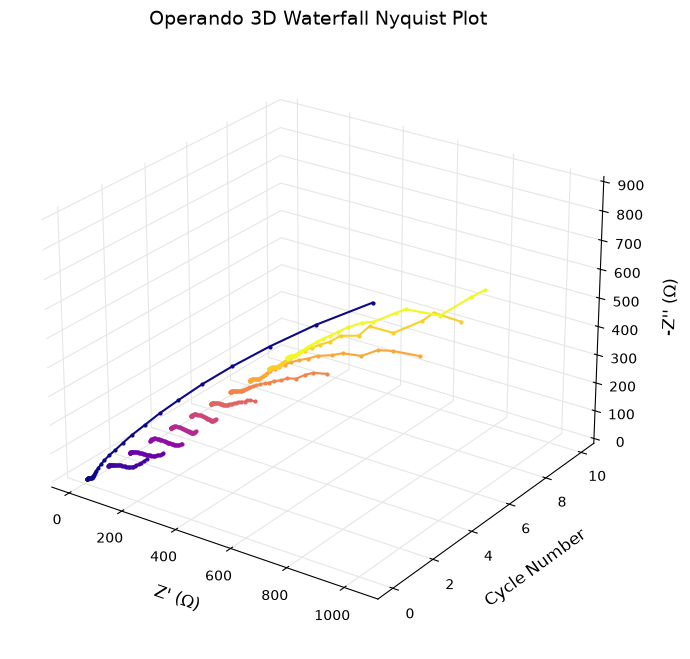

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Create a new figure with 3D projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Get all cycles
cycle_ids = sorted(list(eis_dict.keys()))

# Loop through each cycle and plot it along the Y-axis (depth)
for cycle in cycle_ids:
    freq, Z = eis_dict[cycle]
    
    # Extract real and negative imaginary impedance
    Z_re = Z.real
    Z_im_neg = -Z.imag
    
    # Create an array for the depth axis (Y-axis)
    y_val = np.full_like(Z_re, cycle)
    
    # Use a colormap to give a nice gradient from first to last cycle
    color = cm.plasma(cycle / max(cycle_ids))
    
    # Plot the 3D line
    ax.plot(Z_re, y_val, Z_im_neg, marker='.', markersize=4, 
            linestyle='-', linewidth=1.5, color=color)

# Set axis labels
ax.set_xlabel("Z' ($\Omega$)", fontsize=12, labelpad=10)
ax.set_ylabel("Cycle Number", fontsize=12, labelpad=10)
ax.set_zlabel("-Z'' ($\Omega$)", fontsize=12, labelpad=10)

# Make the background planes (walls) completely transparent!
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# Make the grid lines very faint and clean
ax.xaxis._axinfo["grid"]['color'] = (0.9, 0.9, 0.9, 1)
ax.yaxis._axinfo["grid"]['color'] = (0.9, 0.9, 0.9, 1)
ax.zaxis._axinfo["grid"]['color'] = (0.9, 0.9, 0.9, 1)

# Set a nice default viewing angle (Elevation, Azimuth)
ax.view_init(elev=25, azim=-55)

ax.set_title("Operando 3D Waterfall Nyquist Plot", fontsize=14)

plt.show()


# 2D plot

In [22]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from impedance.visualization import plot_nyquist

# Get all available cycle IDs
cycle_ids = sorted(list(eis_dict.keys()))

def update_multi_plot(cycle_range):
    # Retrieve the start and end cycles from the slider
    start, end = cycle_range
    
    # Create the figure completely from scratch (Best for %matplotlib inline)
    fig, ax_nyq = plt.subplots(figsize=(8, 8))
    
    # Filter for only the cycles within our selected range
    selected_cycles = [c for c in cycle_ids if start <= c <= end]
    
    for c in selected_cycles:
        freq, Z = eis_dict[c]
        
        # Generate a color from the gradient (Plasma: Purple -> Yellow)
        color = cm.plasma(c / max(cycle_ids)) if max(cycle_ids) > 0 else 'blue'
        
        # Plot the actual data
        plot_nyquist(Z, ax=ax_nyq, fmt='.-', color=color)
        
        # Add a dummy line to generate a nice legend label
        ax_nyq.plot([], [], '.-', color=color, label=f'Cycle {c}')
        
    ax_nyq.set_title(f"Operando Nyquist Plot (Cycles {start} to {end})")
    
    # Add a legend and push it just outside the plot so it doesn't cover data
    ax_nyq.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Create an interactive range slider (two handles)
cycle_range_slider = widgets.IntRangeSlider(
    value=[cycle_ids[0], cycle_ids[-1]], # Default to showing all cycles
    min=min(cycle_ids),
    max=max(cycle_ids),
    step=1,
    description='Cycles:',
    continuous_update=False,
    orientation='horizontal'
)

# Link the slider to our update function
widgets.interact(update_multi_plot, cycle_range=cycle_range_slider);


interactive(children=(IntRangeSlider(value=(0, 10), continuous_update=False, description='Cycles:', max=10), O…

## 2. Interactive Visualization
Interactive Nyquist and Bode plots. Since `%matplotlib widget` is enabled, you can zoom, pan, and hover over data points.

In [20]:
def plot_eis_data(freq, Z, title="EIS Measurement"):
    fig, (ax_nyq, ax_bode) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Nyquist Plot
    plot_nyquist(Z, ax=ax_nyq)
    ax_nyq.set_title(f"Nyquist Plot - {title}")
    
    # Bode Plot
    plot_bode(freq, Z, axes=ax_bode)
    ax_bode[0].set_title(f"Bode Plot - {title}")
    
    plt.tight_layout()
    plt.show()

# Example usage (plotting the first loop):
# cycle_id = list(eis_dict.keys())[0]
# freq, Z = eis_dict[cycle_id]
# plot_eis_data(freq, Z, title=f"Operando LiS - Cycle {cycle_id}")

## 3. Equivalent Circuit Modeling & Fitting
Define your equivalent circuit here. 
Since you are working with a LiS battery in a 3-electrode setup, you might start with a Modified Randles circuit, or use multiple RC/RQ elements for the different interfaces (e.g., SEI, charge transfer).

**Common Elements in impedance.py:**
- `R`: Resistor
- `C`: Capacitor
- `CPE`: Constant Phase Element
- `W`: Warburg Element
- `p(R1, C1)`: Parallel elements
- `-`: Series elements

In [ ]:
# Define your circuit model
# Example: R0 + p(R1, CPE1) + p(R2, CPE2) + W1
# circuit_string = 'R0-p(R1,CPE1)-p(R2,CPE2)-W1'
# initial_guess = [10, 50, 1e-4, 0.8, 20, 1e-3, 0.8, 100]

circuit_string = 'R0-p(R1,C1)-W1'
initial_guess = [10, 50, 1e-4, 100] # Provide an initial guess for the parameters

circuit = CustomCircuit(circuit_string, initial_guess=initial_guess)

# To fit the data from the selected cycle:
# circuit.fit(freq, Z)
# print(circuit)

# To plot the fit against the data:
# Z_fit = circuit.predict(freq)
# fig, (ax_nyq, ax_bode) = plt.subplots(1, 2, figsize=(12, 5))
# plot_nyquist(Z, ax=ax_nyq, fmt='o')
# plot_nyquist(Z_fit, ax=ax_nyq, fmt='-')
# plt.legend(['Data', 'Fit'])
# plt.show()

C:\Users\b1104371\AppData\Local\Temp\ipykernel_35144\3188258082.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


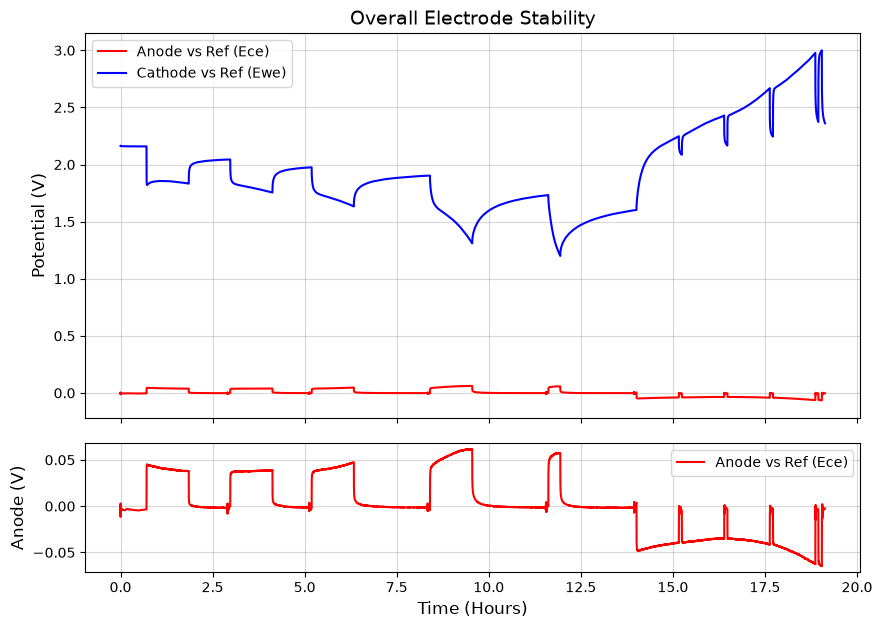

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Re-read the raw file without filtering
skip_rows = 0
with open(data_path, 'r', encoding='latin-1') as f:
    for i, line in enumerate(f):
        if line.startswith('mode'):
            skip_rows = i
            break
            
df_raw = pd.read_csv(data_path, sep='\t', skiprows=skip_rows, encoding='latin-1')

# Parse the time column as real Datetimes
df_raw['time/s'] = pd.to_datetime(df_raw['time/s'], errors='coerce')

# Convert to relative time in hours
df_raw['time/h'] = (df_raw['time/s'] - df_raw['time/s'].iloc[0]) / pd.Timedelta(hours=1)

# Create the plot with a height ratio of 3:1
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 7), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.1})

# --- TOP PLOT: Both Electrodes ---
ax1.plot(df_raw['time/h'], df_raw['Ece/V'], label='Anode vs Ref (Ece)', color='red', linewidth=1.5)
ax1.plot(df_raw['time/h'], df_raw['Ewe/V'], label='Cathode vs Ref (Ewe)', color='blue', linewidth=1.5)
ax1.set_ylabel('Potential (V)', fontsize=12)
ax1.set_title('Overall Electrode Stability', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.5)

# --- BOTTOM PLOT: Anode Focused (Strip) ---
ax2.plot(df_raw['time/h'], df_raw['Ece/V'], label='Anode vs Ref (Ece)', color='red', linewidth=1.5)
ax2.set_xlabel('Time (Hours)', fontsize=12)
ax2.set_ylabel('Anode (V)', fontsize=12)
# Removed title from the bottom plot so it looks more like a continuous strip
ax2.legend(loc='best')
ax2.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()
